## Comparative analysis for the baseline fitting of denatured and folded protein

In this notebook we fit the unfolded baseline to completly unfolded curves based on a temperature window of a set size from the high end of temperatures for curves of 330nm and 350nm. We compare two baseline fitting formulas, quadratic and exponential, and compare them for their ability to generalize to the whole curve. 

### Using the demo DSF data for evaluation of the two formulas

In [1]:
#imports for the plotting of pychemelt
import string

import matplotlib.pyplot as plt
import numpy as np

from pychemelt import Monomer


def model(x, a, b, c=None, kind=None):
    """
    Encoding functions for baseline fitting
    """
    if kind == "linear":
        return a + x * b
    elif kind == "quadratic":
        return a + b*x + c*(x**2)
    elif kind == "exponential":
        return a + b * np.exp(-c * x)
    else:
        raise ValueError("Unknown model type")
    

def rmse(x1, x2):
    """
    Implementation of RMSE
    """
    return np.sqrt(np.mean((x1 - x2)**2))


#okabe ito colorblind friendly colorscheme
okabe_ito = {
    "black":       "#000000",
    "orange":      "#E69F00",
    "skyblue":     "#56B4E9",
    "bluishgreen": "#009E73",
    "yellow":      "#F0E442",
    "blue":        "#0072B2",
    "vermillion":  "#D55E00",
    "reddishpurple": "#CC79A7",
}

### Using the demo baseline and two curves without inflection points as comparison (highest denaturant concentration)

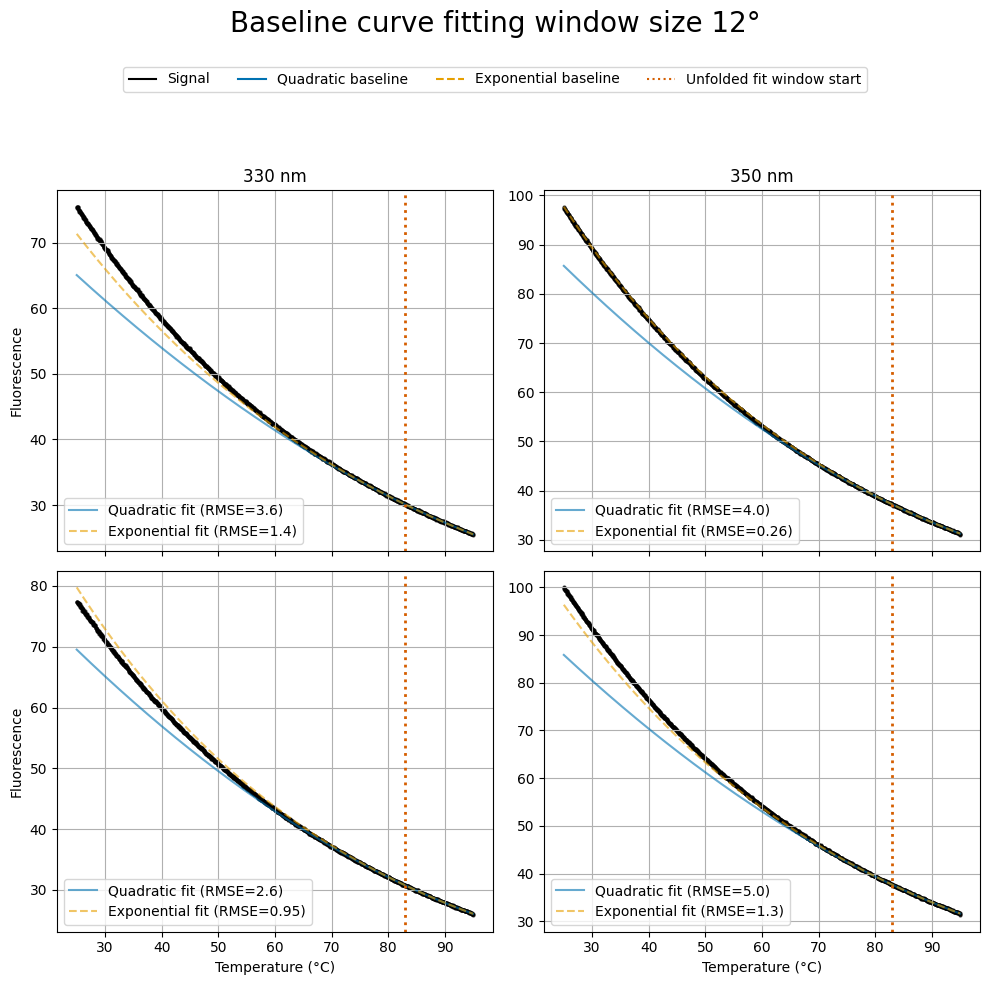

In [2]:


def unfolded_comp(conditions, filename, ws=12): 
    """
    Compare quadratic and exponential unfolded baseline fits for DSF data with unfolded curves.

    This function loads DSF fluorescence data using the pychemelts `Sample`
    interface, estimates unfolded-state baselines using both quadratic and
    exponential models by fitting the curves to the data of the last ws °C, 
    compares their performance using RMSE, and visualizes
    the results for two fluorescence signals (330 nm and 350 nm).

    Parameters
    ----------
    conditions : list of bool
        Boolean mask specifying which experimental conditions are selected
        for analysis. Length must match the number of experiments in the input
        dataset. Typically, `True` values correspond to curves without an
        inflection point used for unfolded baseline estimation.

    filename : str
        Filename of the file containing the DSF data to be used to evaluate 
        the fitting of the unfolded baseline to the unfolded data.

    ws : int, optional, Default 12
        Window size (in °C) used for fitting the unfolded baseline.
        This parameter defines the temperature range over which the baseline
        parameters are estimated. Default is 12.

    Returns
    -------
    None

    Notes
    -----
    - RMSE is computed between the measured fluorescence signal and the fitted
      baseline for each denaturant concentration and signal.
    - Temperatures are internally converted to Kelvin and referenced to 298 K
      before model evaluation.
    - A shared legend and figure-level title are used for visualization.

    Examples
    --------
    >>> conditions = (
    ...     [False] * 18
    ...     + [True] * 3
    ...     + [False] * (48 - 21)
    ... )
    >>> unfolded_comp(conditions, ws=12)
    """
        
    #using pychemelts sample structure for the loading of the data and prediction

    sample = Monomer()
    sample.read_multiple_files(filename)
    sample.set_denaturant_concentrations()

    #usage of 330nm and 350nm for the initial curves
    sample.set_signal(["330nm", "350nm"])
    
    #experiments used for evaluation, should be curves without inflection 
    sample.select_conditions(conditions)    


    #fit the baselines as quadratic curve
    sample.estimate_baseline_parameters(
        native_baseline_type="linear",
        unfolded_baseline_type="quadratic",
        window_range_unfolded=ws
    )

    a_quas = sample.first_param_Us_per_signal
    b_quas = sample.second_param_Us_per_signal
    c_quas = sample.third_param_Us_per_signal

    #fit the baselines as exponential curve
    sample.estimate_baseline_parameters(
        native_baseline_type="linear",
        unfolded_baseline_type="exponential",
        window_range_unfolded=ws
    )

    a_exps = sample.first_param_Us_per_signal
    b_exps = sample.second_param_Us_per_signal
    c_exps = sample.third_param_Us_per_signal

    #assigning preprocessed signal and temperature for plotting
    temperature = sample.temp_lst_multiple[0][0]     
    fluorescences = sample.signal_lst_multiple  

    
    #using the removed reference temperature for plotting
    temperature_K = temperature + 273.15
    temperature_K_ref = temperature_K - 298

    #creating all formula results for comparison and plots

    fig, axes = plt.subplots(
    ncols=2,
    nrows=sample.nr_den,
    figsize=(10, 5 * sample.nr_den),
    sharex=True,
    )

    T_window_start = temperature.max() - ws

    for i in range(2):    # 330nm and 350nm

        for j in range(sample.nr_den):
            
            ax = axes[j, i]

            qua_bl = model(temperature_K_ref,
                a_quas[i][j],
                b_quas[i][j],
                c_quas[i][j],
                kind="quadratic")


            exp_bl = model(temperature_K_ref,
                a_exps[i][j],
                b_exps[i][j],
                c_exps[i][j],
                kind="exponential")



            #plotting the results
            ax.scatter(
                temperature,
                fluorescences[i][j],
                s=4,
                color=okabe_ito["black"],
                alpha=0.7,
            )

            ax.plot(
                temperature,
                qua_bl,
                color=okabe_ito["blue"],
                alpha=0.6,
                label=f"Quadratic fit (RMSE={rmse(fluorescences[i][j], qua_bl):.2})",
            )

            ax.plot(
                temperature,
                exp_bl,
                color=okabe_ito["orange"],
                linestyle="--",
                alpha=0.6,
                label=f"Exponential fit (RMSE={rmse(fluorescences[i][j], exp_bl):.2})",
            )

            ax.axvline(
                T_window_start,
                color=okabe_ito["vermillion"],
                linestyle=":",
                linewidth=2,
            )


            if j == 0:
                ax.set_title(["330 nm", "350 nm"][i])

            if i == 0:
                ax.set_ylabel("Fluorescence")

            ax.legend()
            ax.grid(True)

        
        ax.set_xlabel("Temperature (°C)")



    # manual legend (once)
    handles = [
        plt.Line2D([0], [0], color=okabe_ito["black"], label="Signal"),
        plt.Line2D([0], [0], color=okabe_ito["blue"], label="Quadratic baseline"),
        plt.Line2D([0], [0], color=okabe_ito["orange"], linestyle="--", label="Exponential baseline"),
        plt.Line2D([0], [0], color=okabe_ito["vermillion"], linestyle=":", label="Unfolded fit window start"),
    ]

    fig.suptitle("Baseline curve fitting window size " + str(ws) + "°", fontsize=20)
    fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.93))
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()


#using a demo file
filename="../data/nDSFdemoFile.xlsx"

#selecting two curves with no detectable inflection point as an unfolded baseline
conditions = [False] * 19 + [True] * 2 + [False] * (48 - 21)

# using the default window size

unfolded_comp(conditions, filename)



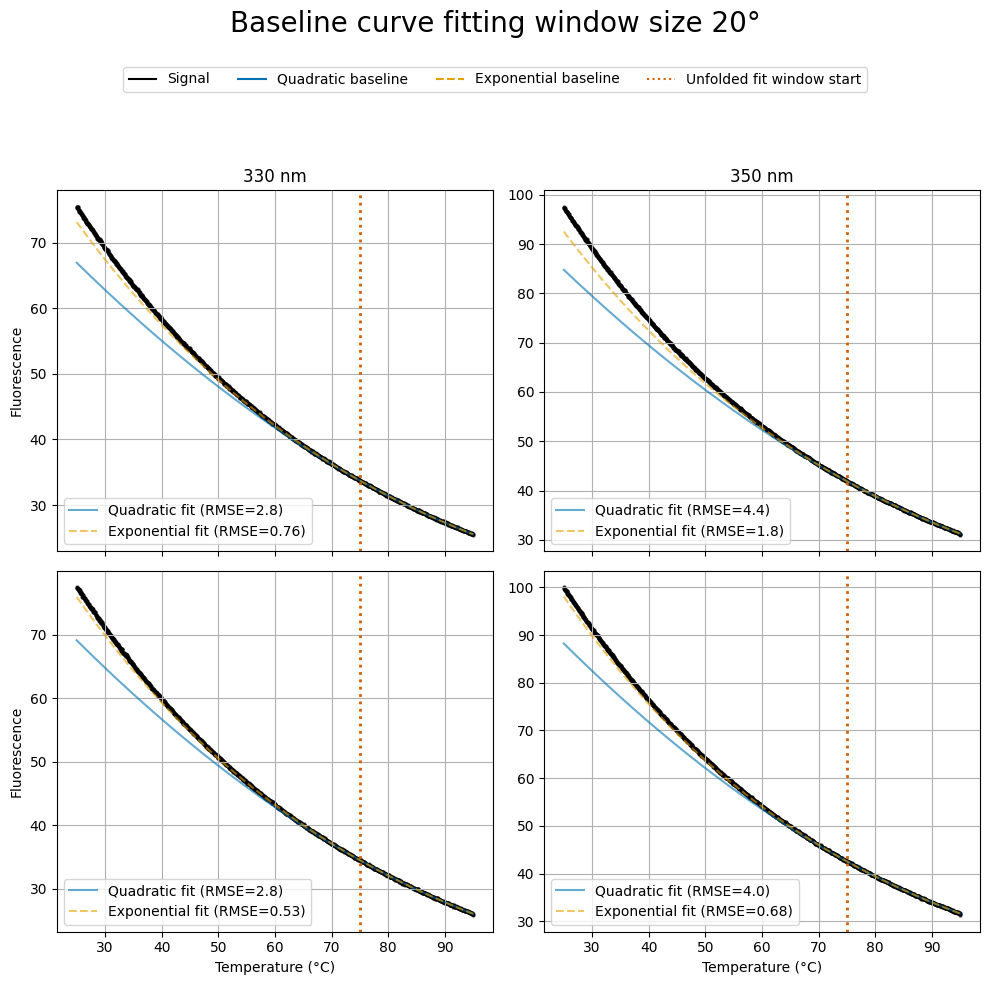

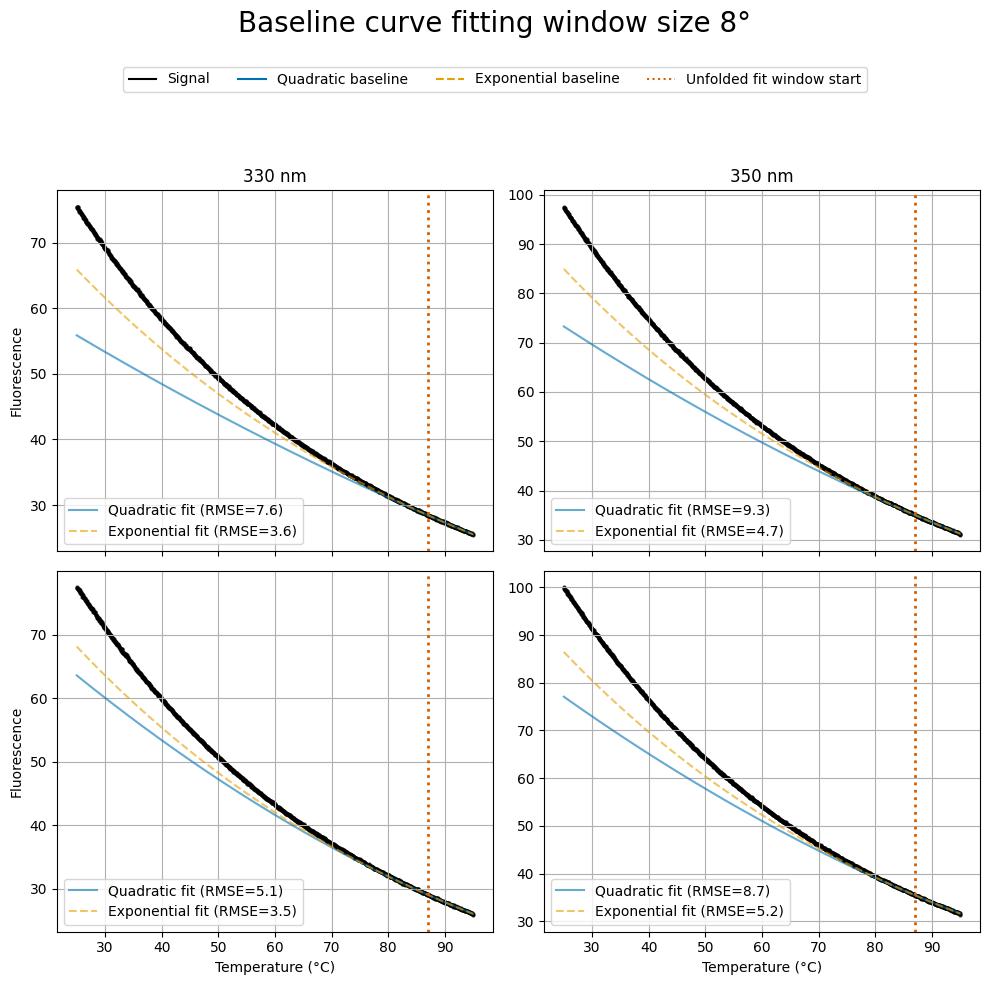

In [3]:
#comparing the fits using different window sizes

unfolded_comp(conditions, filename, ws=20)

unfolded_comp(conditions, filename, ws=8)


### Using a dataset containing curves for the ACBP dataset

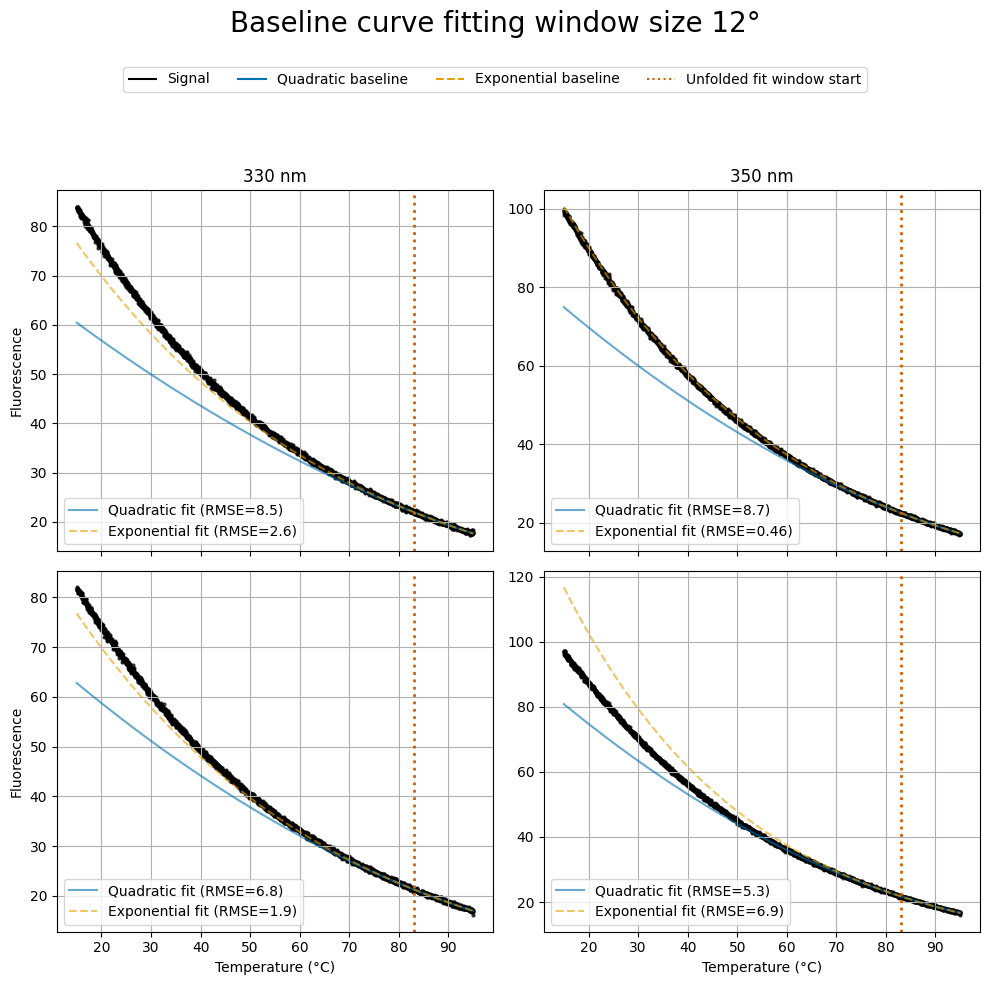

In [4]:
#using unfolded curves of the ACBP dataset

# selecting two curves with the highest denaturant concentration

conditions_nf = [True] * 2 + [False] * (16 - 2)

filename = "../data/20191202_ACBP_15C_95C_processed.xlsx"

# using the default window size

unfolded_comp(conditions_nf, filename)

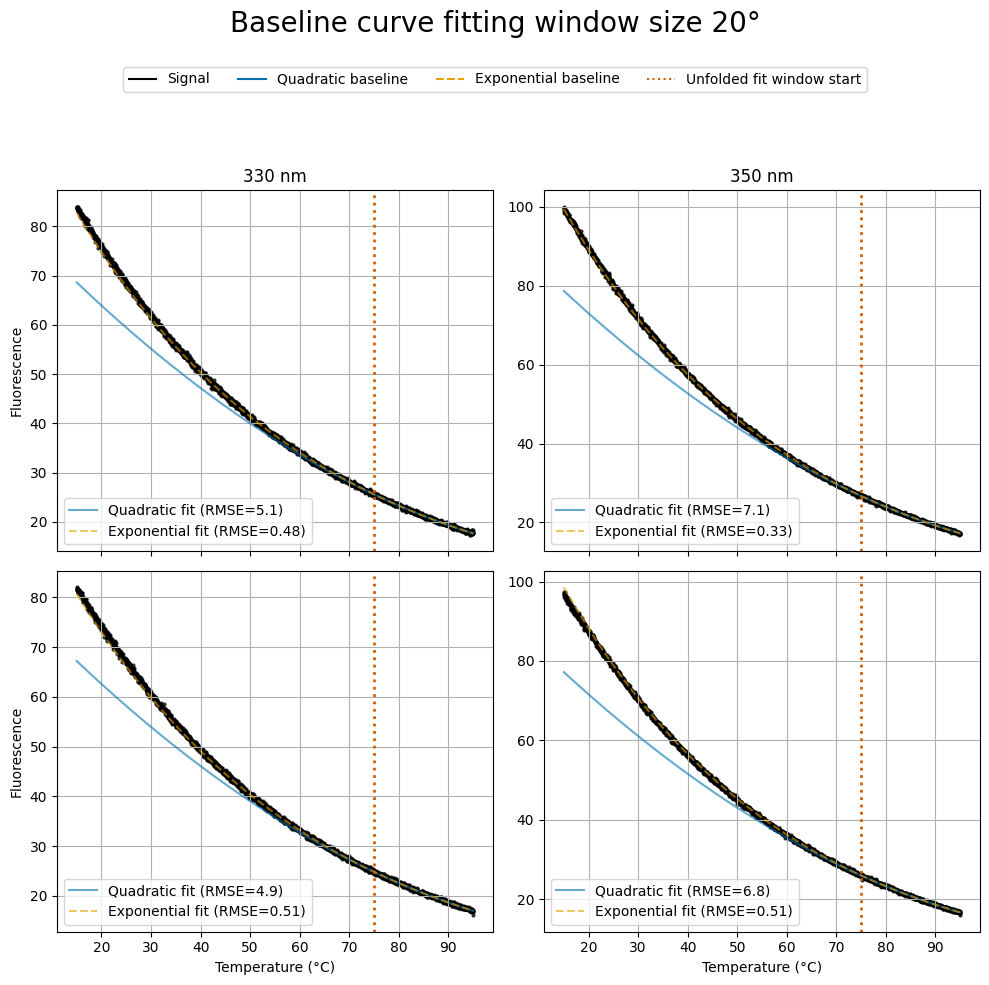

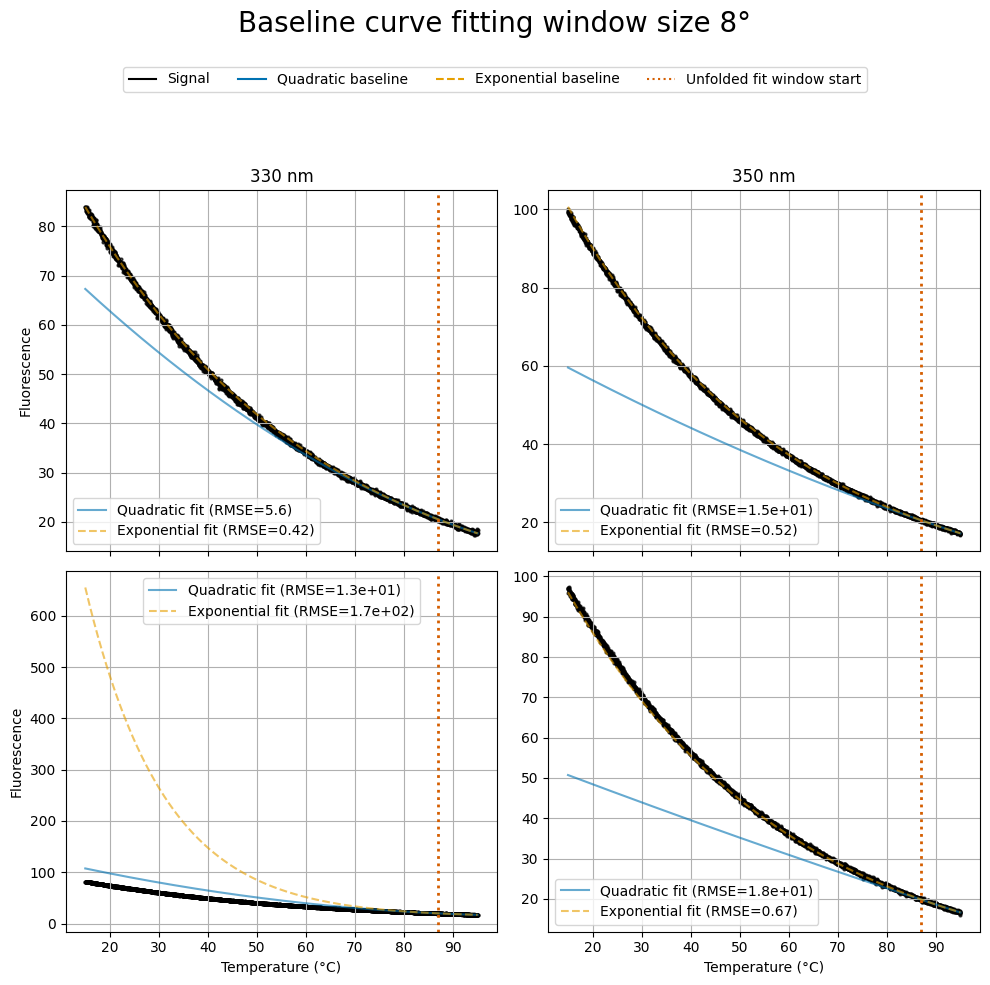

In [5]:
#comparing the fits using different window sizes

unfolded_comp(conditions_nf, filename, ws=20)

unfolded_comp(conditions_nf, filename, ws=8)



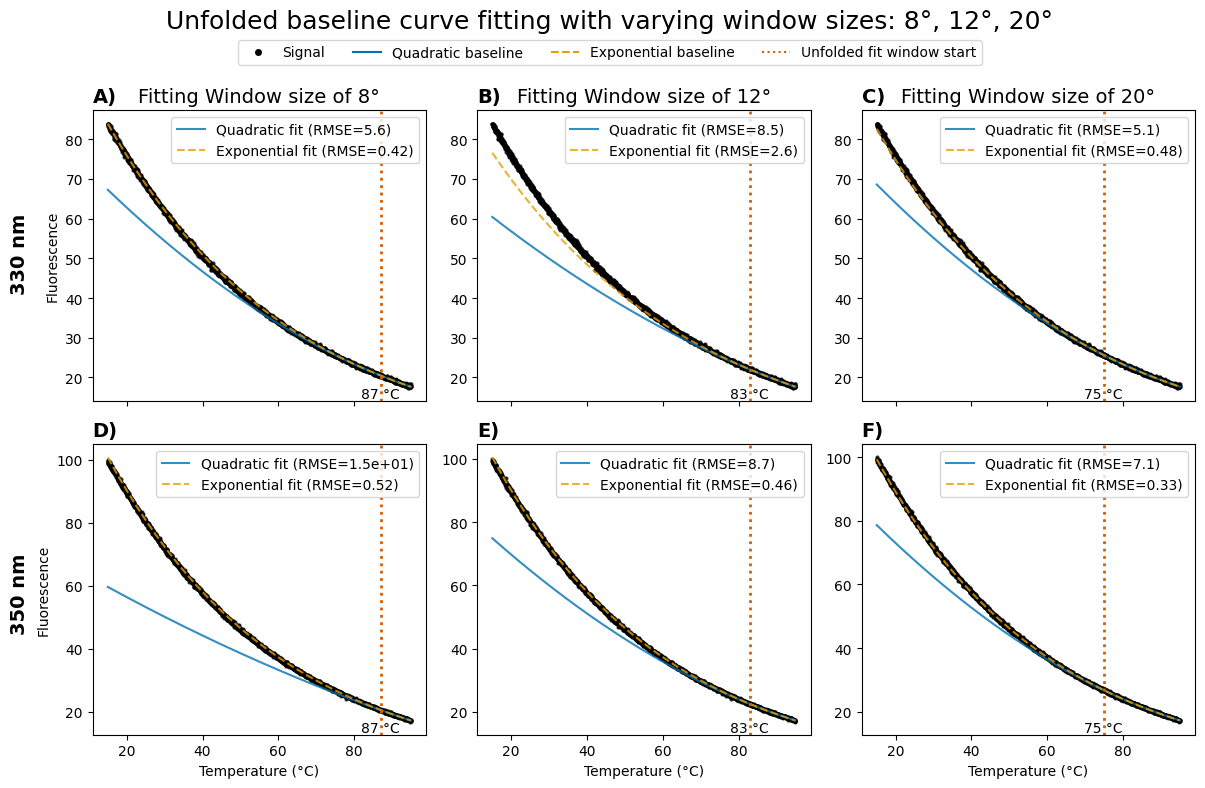

In [6]:
def unfolded_comp_fig(condition, filename, windows=[12]): 
    """
    Compare quadratic and exponential unfolded baseline fits for DSF data with an unfolded curve.

    This function loads DSF fluorescence data using the pychemelts `Sample`
    interface, estimates unfolded-state baselines using both quadratic and
    exponential models by fitting the curves to the data of the last °C of 
    different window sizes given in windows, 
    compares their performance using RMSE, and visualizes
    the results for two fluorescence signals (330 nm and 350 nm).

    Parameters
    ----------
    condition : list of bool
        Boolean mask specifying which experimental condition is selected
        for analysis. Length must match the number of experiments in the input
        dataset. The one selected curve should represent a fully unfolded curve

    filename : str
        Filename of the file containing the DSF data to be used to evaluate 
        the fitting of the unfolded baseline to the unfolded data.
    
    windows : int, optional, Default [12]
        Window sizes (in °C) used for fitting the unfolded baseline.
        This parameter defines the temperature range over which the baseline
        parameters are estimated. Default is [12].

    Returns
    -------
    fig: object
        The matplotlib figure object

    Notes
    -----
    - RMSE is computed between the measured fluorescence signal and the fitted
      baseline for each denaturant concentration and signal.
    - Temperatures are internally converted to Kelvin and referenced to 298 K
      before model evaluation.
    - A shared legend and figure-level title are used for visualization.

    Examples
    --------
    >>> conditions = (
    ...     [False] * 20
    ...     + [True] * 1
    ...     + [False] * (48 - 21)
    ... )
    >>> unfolded_comp_fig(conditions, ws=[12])
    """

    if not isinstance(windows, list):
        windows = [windows]

    fig, axes = plt.subplots(
    ncols=len(windows),
    nrows=2,
    figsize=(4 * len(windows), 8),
    sharex=True,
    )

    for j, ws in enumerate(windows):

        #using pychemelts sample structure for the loading of the data and prediction

        sample = Monomer()
        sample.read_multiple_files(filename)
        sample.set_denaturant_concentrations()

        #usage of 330nm and 350nm for the initial curves
        sample.set_signal(["330nm", "350nm"])
        
        #experiments used for evaluation, should be curves without inflection 
        sample.select_conditions(condition)    


        #fit the baselines as quadratic curve
        sample.estimate_baseline_parameters(
            native_baseline_type="linear",
            unfolded_baseline_type="quadratic",
            window_range_unfolded=ws
        )

        a_quas = sample.first_param_Us_per_signal
        b_quas = sample.second_param_Us_per_signal
        c_quas = sample.third_param_Us_per_signal

        #fit the baselines as exponential curve
        sample.estimate_baseline_parameters(
            native_baseline_type="linear",
            unfolded_baseline_type="exponential",
            window_range_unfolded=ws
        )

        a_exps = sample.first_param_Us_per_signal
        b_exps = sample.second_param_Us_per_signal
        c_exps = sample.third_param_Us_per_signal

        #assigning preprocessed signal and temperature for plotting
        temperature = sample.temp_lst_multiple[0][0]     
        fluorescences = sample.signal_lst_multiple  

        
        #using the removed reference temperature for plotting
        temperature_K = temperature + 273.15
        temperature_K_ref = temperature_K - 298

        #creating all formula results for comparison and plots

        T_window_start = temperature.max() - ws

        for i in range(2):    # 330nm and 350nm

            if len(windows) == 1:
                ax = axes[i]
            else:
                ax = axes[i, j]

            qua_bl = model(temperature_K_ref,
                a_quas[i][0],
                b_quas[i][0],
                c_quas[i][0],
                kind="quadratic")


            exp_bl = model(temperature_K_ref,
                a_exps[i][0],
                b_exps[i][0],
                c_exps[i][0],
                kind="exponential")



            #plotting the results
            ax.scatter(
                temperature,
                fluorescences[i][0],
                s=4,
                color=okabe_ito["black"],
                alpha=0.7,
            )

            ax.plot(
                temperature,
                qua_bl,
                color=okabe_ito["blue"],
                alpha=0.8,
                label=f"Quadratic fit (RMSE={rmse(fluorescences[i][0], qua_bl):.2})",
            )

            ax.plot(
                temperature,
                exp_bl,
                color=okabe_ito["orange"],
                linestyle="--",
                alpha=0.8,
                label=f"Exponential fit (RMSE={rmse(fluorescences[i][0], exp_bl):.2})",
            )

            ax.axvline(
                T_window_start,
                color=okabe_ito["vermillion"],
                linestyle=":",
                linewidth=2,
            )

            ax.text(
                T_window_start+5,
                ax.get_ylim()[0],                
                f"{int(T_window_start)} °C",
                color="black",
                ha="right",
                va="bottom",
                fontsize=10,
            )           

            if i == 0:
                ax.set_title(f"Fitting Window size of {ws}°", fontsize=14)

            # panel label
            if len(windows) == 1:
                label_idx = i
            else:
                label_idx = i * axes.shape[1] + j


            ax.set_title(f"{string.ascii_uppercase[label_idx]})", loc="left", fontsize=14,
                fontweight="bold",)


            if j == 0:
                ax.set_ylabel("Fluorescence")

            ax.legend(loc='upper right')
            #ax.grid(True)

            if i == 1:
                ax.set_xlabel("Temperature (°C)")



        # manual legend (once)
        handles = [
            plt.Line2D([0], [0], color=okabe_ito["black"], linestyle='None', marker='o', markersize=4, label="Signal"),
            plt.Line2D([0], [0], color=okabe_ito["blue"], label="Quadratic baseline"),
            plt.Line2D([0], [0], color=okabe_ito["orange"], linestyle="--", label="Exponential baseline"),
            plt.Line2D([0], [0], color=okabe_ito["vermillion"], linestyle=":", label="Unfolded fit window start"),
        ]

    ws_str = [str(x)for x in windows]

    fig.suptitle("Unfolded baseline curve fitting with varying window sizes: " + "°, ".join(ws_str) + "°", fontsize=18)
    fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.95))
    
    # Row labels for signals
    row_labels = ["330 nm", "350 nm"]

    # Y positions are in figure coordinates (0–1)
    for i, label in enumerate(row_labels):
        fig.text(
            0.0,                       # x position (left margin)
            0.675 - i * 0.425,             # y position (top to bottom)
            label,
            va="center",
            ha="left",
            rotation=90,
            fontsize=14,
            fontweight="bold",
        )
    
    fig.tight_layout(rect=[0.01, 0, 1, 0.95])
    
    
    return fig


#using unfolded curves of the ACBP dataset

# selecting the curve with highest denaturant concentration as only unfolded sample

conditions_nf = [True] * 1 + [False] * 15

filename = "../data/20191202_ACBP_15C_95C_processed.xlsx"

# using the default window size

fig = unfolded_comp_fig(conditions_nf, filename, windows=[8, 12, 20])

fig.savefig("1_exp_quad_fit_analysis_ACBP.png")

When choosing a formula, the exponential function models the unfolded baseline generally more accuratly than the quadratic function for 330nm and 350nm. However, the exponential function is more unstable with insufficient data while the quadratic function does not deviate as extremly so in cases with where only a limited unfolded state window is available caution is advised when using exponential.